In [1]:
import os
import numpy as np
import pandas as pd
from datetime import date, timedelta

import colorcet as cc
from cmcrameri import cm
import matplotlib as mpl
import matplotlib.pyplot as plt
import proplot as pplt

#warning
import warnings
warnings.filterwarnings('ignore')


from config import (
    dir_in, dir_out,
    dir_flow_managed, dir_flow_natural, dir_flow_v1,
    dir_ref, path_grdc_stations, path_grdc_csv,
    dir_grand, coastlines_path,
    dir_usgrid, dir_calibration_results, dir_sensitivity,
)


/Users/abes208/miniforge3/envs/xanthos-wm-figures/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
#############################################################
basinName = pd.read_csv(dir_in + '/BasinNames235.txt')
basin_id = pd.read_csv(dir_in + '/basin.csv')
GRDC_xanthosCoordIndx = pd.read_csv(dir_in + '/GRDC_stations_list.csv')
basins94 = np.array(GRDC_xanthosCoordIndx['basins']).astype(np.int64)
xanthosid = np.array(GRDC_xanthosCoordIndx['xanthosID_new_adj']).astype(np.int64)
basinName_94 = [basinName['Basin_Name'][basins94[ii] - 1] for ii in range(GRDC_xanthosCoordIndx.shape[0])]

In [3]:
def runoff_model_output(dir_in, basin_num):
    #os.chdir(dir_in)
    basin_calibration =  pd.read_csv(dir_in + '/basin_calibration_' + str(basin_num) + 'c.csv')
    basin_calibration = basin_calibration.drop(columns=['para',	'parb',	'parc',	'pard',	'parm'])
    ## basin_abcd
    basin_abcd = basin_calibration[['simulation1_1', 'simulation1_2', 'simulation1_3', 'simulation1_4', 'simulation1_5']]
    basin_abcd.columns = ['par_a',	'par_b',	'par_c',	'par_d',	'par_m']

    return basin_abcd


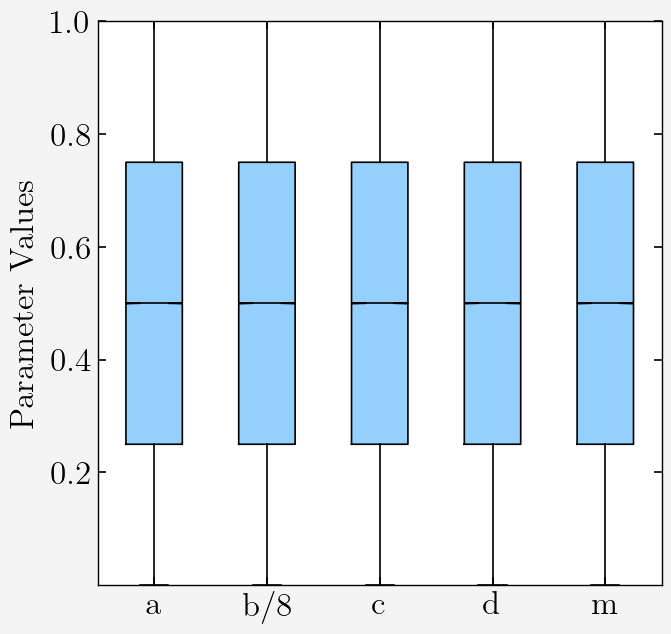

In [4]:
start_yr = 1971
ending_yr = 1990

SAVE_KWDS = {"bbox_inches": "tight", "dpi": 450, "facecolor": "w"}
BASE_PLOT = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9,}
plt.rcParams['figure.autolayout'] = True 
plt.rcParams.update({'font.size': 12}) 

basin_num = 6
bb = np.where(basins94==basin_num)[0]
## Get data : simulated   
basin_abcd = runoff_model_output(dir_in + '/WATCH-1M-Run-abcdm/', basin_num)
basin_abcd['par_b'] = basin_abcd['par_b']/8
basin_abcd.columns = ['a','b','c','d','m']
##################################################
import scienceplots
plt.style.use('science')
with plt.style.context(['science', 'high-contrast']):
    fig, axs = pplt.subplots(nrows=1, ncols=1,  share=1, journal='pnas1')
    ax = axs[0]
    ax.boxplot(np.array(basin_abcd), notch=True ,facecolor='light blue')
    ax.set_xticklabels(['a','b/8','c','d','m'])
    ax.autoscale(tight=True)      
    ax.format(ylabel='Parameter Values' , fontsize= 12)  
    ax.format(ylabel='Parameter Values', abcstyle=False,  grid=False)   
    ax.minorticks_off()


plt.tight_layout()   
#dir_out = dir_out
#plt.savefig(dir_out + "Figure-5.png", **SAVE_KWDS)  